# 02 Correlation Analysis — Data Guide

ก่อน run analysis ขอ map ว่าแต่ละ dataset ที่เราเลือกมา **ตอบคำถามอะไร** และ **ทำไมต้องใช้ตัวนี้**

---

## 9 ปัจจัยที่ขับเคลื่อนเศรษฐกิจ

| # | ปัจจัย | Dataset ที่ใช้ | Frequency |
|---|---|---|---|
| 1 | **Consumption** — คนกล้าใช้เงินไหม | `consumption_pct_gdp`, `th_property_prices`, `us_consumer_sentiment` | Annual / Quarterly / Monthly |
| 2 | **Interest Rate** — ดอกเบี้ยแพงแค่ไหน | `lending_rate`, `us_10yr_treasury`, `us_fed_funds_rate`, `policy_rate_monthly` | Annual / Daily / Monthly |
| 3 | **Inflation** — ของแพงแค่ไหน | `inflation`, `us_cpi_monthly`, `cpi_monthly` | Annual / Monthly |
| 4 | **Unemployment** — คนตกงานเยอะไหม | `unemployment`, `us_unemployment` | Annual / Monthly |
| 5 | **Business Investment** — บริษัทกล้าลงทุนไหม | `gross_capital_formation`, `us_industrial_prod` | Annual / Monthly |
| 6 | **Trade & Exports** — โลกซื้อของไทยไหม | `exports_pct_gdp`, `imports_pct_gdp`, `USD_THB`, `th_exchange_rate_real`, `th_us_imports`, `oil` | Mixed |
| 7 | **Geopolitical Risk** — นักลงทุนกลัวแค่ไหน | `vix`, `gold`, `th_uncertainty`, `global_uncertainty`, `news_sentiment` | Daily / Quarterly / Monthly |
| 8 | **Technology** — sector เทคโนโลยีโต/หด | `nasdaq`, `us_industrial_prod`, `gdp_growth` | Daily / Monthly / Annual |
| 9 | **Government Policy** — รัฐกระตุ้นหรือรัดเข็มขัด | `govt_expenditure`, `govt_debt`, `us_fed_funds_rate` | Annual / Monthly |

---

## ทำไมถึงใช้ข้อมูล US/Global แทน Thailand รายเดือน?

> ไทยส่งออกประมาณ **70% of GDP** — เมื่อ US/Global economy เปลี่ยน ไทยรู้สึกภายใน **1-3 เดือน**

FRED (Federal Reserve) มี Thailand data เฉพาะรายปีเป็นส่วนใหญ่ แต่ US/Global indicators รายเดือนมีครบและ reliable:

| FRED Series | ชื่อ | ทำไมสำคัญกับไทย |
|---|---|---|
| `FEDFUNDS` | US Federal Funds Rate | เมื่อ Fed ขึ้นดอกเบี้ย → เงินทุนไหลออกจาก emerging markets รวมถึงไทย |
| `CPIAUCSL` | US CPI (Inflation) | US inflation สูง → Fed ขึ้นดอกเบี้ย → กดดันเงินบาท |
| `UNRATE` | US Unemployment | US คนตกงานเยอะ → ซื้อของจากไทยน้อยลง → ส่งออกไทยลด |
| `INDPRO` | US Industrial Production | proxy ความต้องการสินค้าจากโรงงานไทย |
| `GEPUCURRENT` | Global Policy Uncertainty | ความไม่แน่นอนโลก → นักลงทุนถอนเงินออกจากไทย |
| `UMCSENT` | US Consumer Sentiment | คนอเมริกันมั่นใจ → ซื้อของมากขึ้น → ดีกับส่งออกไทย |

---

## Thailand-specific จาก FRED

| FRED Series | ชื่อ | Factor |
|---|---|---|
| `RBTHBIS` | Real Effective Exchange Rate | factor 6: ค่าเงินบาทเทียบตะกร้าสกุลเงิน |
| `IMP5490` | US Imports from Thailand | factor 6: วัดความต้องการสินค้าไทยจาก US |
| `QTHR628BIS` | Bangkok Property Prices | factor 1: proxy การบริโภค / ความมั่งคั่ง |
| `WUITHA` | World Uncertainty Index TH | factor 7: ความไม่แน่นอนเฉพาะในไทย |

---

## Market Signals จาก yfinance (รายวัน)

| Ticker | ชื่อ | Factor | Logic |
|---|---|---|---|
| `^SET.BK` | SET Index | target | ตลาดหุ้นไทย — mirror ของ sentiment เศรษฐกิจ |
| `THB=X` | USD/THB | 6 | ค่าบาทแข็ง → ส่งออกแพงขึ้น → กระทบ competitiveness |
| `^VIX` | VIX Fear Index | 7 | VIX > 30 = ตลาดกลัวมาก → เงินไหลออก EM |
| `GC=F` | Gold | 7 | ทองขึ้นเมื่อคนกลัว → inverse กับ risk appetite |
| `^GSPC` | S&P 500 | 6, 8 | global risk appetite — ถ้า S&P ลง EM มักลงด้วย |
| `CL=F` | Crude Oil | 6 | ไทยนำเข้าน้ำมัน — น้ำมันแพง → ต้นทุนสูง → inflation |
| `^TNX` | US 10-yr Treasury | 2 | yield สูง → ดึงเงินจาก EM → บาทอ่อน |
| `^IXIC` | Nasdaq | 8 | tech sector — indicator ของ innovation cycle โลก |

---

## ข้อควรระวังก่อน interpret ผล

1. **Frequency ต่างกัน** — macro รายปีกับ market รายวันเปรียบตรงๆ ไม่ได้ ต้อง aggregate ก่อน
2. **Correlation ≠ Causation** — ตัวเลขสูงไม่แปลว่า X ทำให้เกิด Y
3. **Granger causality** บอกได้แค่ว่า X มีข้อมูลช่วยทำนาย Y — ไม่ใช่เหตุผลจริง
4. **Macro data น้อย** — World Bank ให้แค่ ~25 ปี → statistical power ต่ำ ต้องระวังการ overfit
5. **IMF data** — tail ที่เห็นอาจเป็น forecast ไม่ใช่ historical → filter `year <= 2025` แล้ว


# 02 Correlation Analysis

วิเคราะห์ความสัมพันธ์ระหว่างตัวแปรทั้งหมด:
- Pearson correlation
- Lagged correlation (ตัวแปรไหนนำ/ตาม)
- Granger causality
- Rolling correlation

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import grangercausalitytests

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 50)

PROC_DIR = Path('../../data/processed')
RAW_DIR  = Path('../../data/raw')

# ── Load unified monthly dataset (output from 02_data_cleaning.ipynb) ─────────
unified = pd.read_csv(PROC_DIR / 'unified_monthly.csv', index_col=0, parse_dates=True)

# ── Split into logical groups ──────────────────────────────────────────────────
MARKET_RET_COLS = [c for c in unified.columns if c.endswith('_ret_m')]
MARKET_PRC_COLS = [c for c in unified.columns if c.endswith('_price')]
FRED_COLS       = [c for c in unified.columns if not c.endswith(('_ret_m','_price','_annual'))]
MACRO_COLS      = [c for c in unified.columns if c.endswith('_annual')]

market_ret  = unified[MARKET_RET_COLS].dropna(how='all')
market_prc  = unified[MARKET_PRC_COLS].dropna(how='all')
fred_level  = unified[FRED_COLS].dropna(how='all')
macro       = unified[MACRO_COLS].dropna(how='all')

# Monthly % change for FRED (removes trend, shows co-movement)
fred_ret = fred_level.pct_change().replace([np.inf, -np.inf], np.nan).dropna(how='all')

# Daily market data (for rolling & lagged correlation)
market_daily = pd.read_csv(PROC_DIR / 'market_daily_clean.csv', index_col=0, parse_dates=True)
daily_ret = market_daily.pct_change().dropna(how='all')

print(f"unified       : {unified.shape}  ({unified.index[0].date()} → {unified.index[-1].date()})")
print(f"market_ret    : {market_ret.shape}   {list(market_ret.columns)}")
print(f"fred_level    : {fred_level.shape}   {list(fred_level.columns)}")
print(f"fred_ret      : {fred_ret.shape}")
print(f"macro         : {macro.shape}   {list(macro.columns)}")
print(f"market_daily  : {market_daily.shape}")


unified       : (276, 37)  (2003-01-31 → 2025-12-31)
market_ret    : (275, 8)   ['SET_index_ret_m', 'USD_THB_ret_m', 'vix_ret_m', 'gold_ret_m', 'oil_ret_m', 'sp500_ret_m', 'us_10yr_treasury_ret_m', 'nasdaq_ret_m']
fred_level    : (276, 11)   ['th_exchange_rate_real', 'th_us_imports', 'th_property_prices', 'th_uncertainty', 'us_fed_funds_rate', 'us_cpi_monthly', 'us_unemployment', 'us_industrial_prod', 'global_uncertainty', 'us_consumer_sentiment', 'us_govt_spending']
fred_ret      : (275, 11)
macro         : (276, 10)   ['consumption_annual', 'lending_rate_annual', 'inflation_annual', 'unemployment_annual', 'business_invest_annual', 'exports_pct_gdp_annual', 'imports_pct_gdp_annual', 'gdp_growth_annual', 'govt_expenditure_annual', 'govt_debt_annual']
market_daily  : (6000, 8)


In [2]:
def read_market(name):
    df = pd.read_csv(RAW_DIR / f'{name}_market_signals.csv')
    df['date'] = pd.to_datetime(df['date'])
    df['close'] = pd.to_numeric(df['close'], errors='coerce')
    return df.set_index('date')[['close']].rename(columns={'close': name})

def read_macro(filename, col_name):
    df = pd.read_csv(RAW_DIR / filename)
    df['year'] = pd.to_numeric(df['year'], errors='coerce')
    df['value'] = pd.to_numeric(df['value'], errors='coerce')
    return df.set_index('year')[['value']].rename(columns={'value': col_name})

def read_fred(name):
    """Load a FRED monthly series: date, value, series → DatetimeIndex with col=name"""
    df = pd.read_csv(RAW_DIR / f'fred_{name}.csv')
    df['date'] = pd.to_datetime(df['date'])
    df['value'] = pd.to_numeric(df['value'], errors='coerce')
    return df.set_index('date')[['value']].rename(columns={'value': name})

# --- Market signals (daily) — covers factors 2,6,7,8 ---
market = pd.concat([
    read_market('SET_index'),
    read_market('USD_THB'),
    read_market('gold'),
    read_market('oil'),
    read_market('sp500'),
    read_market('vix'),
    read_market('us_10yr_treasury'),  # factor 2: interest rate benchmark
    read_market('nasdaq'),            # factor 8: technology
], axis=1).sort_index()

returns = market.pct_change().dropna()

# --- Macro annual (World Bank / IMF) — historical <=2025 ---
macro = pd.concat([
    read_macro('consumption_pct_gdp_TH.csv',     'consumption'),       # factor 1
    read_macro('lending_rate_TH.csv',             'lending_rate'),      # factor 2
    read_macro('inflation_TH.csv',                'inflation'),          # factor 3
    read_macro('thailand_unemployment_rate.csv',  'unemployment'),       # factor 4
    read_macro('gross_capital_formation_TH.csv',  'business_invest'),   # factor 5
    read_macro('exports_pct_gdp_TH.csv',          'exports_pct_gdp'),   # factor 6
    read_macro('imports_pct_gdp_TH.csv',          'imports_pct_gdp'),   # factor 6
    read_macro('imf_gdp_growth_TH.csv',           'gdp_growth'),         # factor 8 proxy
    read_macro('govt_expenditure_pct_gdp_TH.csv', 'govt_expenditure'),  # factor 9
    read_macro('govt_debt_pct_gdp_TH.csv',        'govt_debt'),          # factor 9
], axis=1).sort_index()
macro = macro[macro.index <= 2025]

# --- FRED monthly (high-frequency proxies) ---
fred_monthly = pd.concat([
    read_fred('th_exchange_rate_real'),   # factor 6: trade competitiveness
    read_fred('th_us_imports'),           # factor 6: US demand for Thai goods
    read_fred('th_property_prices'),      # factor 1: domestic consumption signal
    read_fred('th_uncertainty'),          # factor 7: geopolitical risk
    read_fred('us_fed_funds_rate'),       # factor 2: global interest rate anchor
    read_fred('us_cpi_monthly'),          # factor 3: global inflation signal
    read_fred('us_unemployment'),         # factor 4: global demand proxy
    read_fred('us_industrial_prod'),      # factor 5: global investment cycle
    read_fred('global_uncertainty'),      # factor 7: EPU index
    read_fred('us_consumer_sentiment'),   # factor 1/8: consumer confidence
    read_fred('us_govt_spending'),        # factor 9: US fiscal stance
], axis=1).sort_index()

# Resample FRED to monthly end-of-month to align for correlation
fred_monthly = fred_monthly.resample('ME').last()
fred_returns = fred_monthly.pct_change().dropna(how='all')

# News sentiment monthly (factor 7: confidence proxy)
news = pd.read_csv(RAW_DIR / 'news_sentiment.csv')
news['published_dt'] = pd.to_datetime(news['published'], errors='coerce')
news['month'] = news['published_dt'].dt.to_period('M').dt.to_timestamp()
news_monthly = news.groupby('month')['compound'].mean().rename('sentiment_score')

print(f"market      : {market.shape}  cols={list(market.columns)}")
print(f"returns     : {returns.shape}")
print(f"macro       : {macro.shape}")
print(f"fred_monthly: {fred_monthly.shape}  cols={list(fred_monthly.columns)}")
print(f"\nmacro tail (historical):")
print(macro.dropna(how='all').tail(6))
print(f"\nfred_monthly tail:")
print(fred_monthly.dropna(how='all').tail(3))


market      : (6088, 8)  cols=['SET_index', 'USD_THB', 'gold', 'oil', 'sp500', 'vix', 'us_10yr_treasury', 'nasdaq']
returns     : (4746, 8)
macro       : (25, 10)
fred_monthly: (280, 11)  cols=['th_exchange_rate_real', 'th_us_imports', 'th_property_prices', 'th_uncertainty', 'us_fed_funds_rate', 'us_cpi_monthly', 'us_unemployment', 'us_industrial_prod', 'global_uncertainty', 'us_consumer_sentiment', 'us_govt_spending']

macro tail (historical):
      consumption  lending_rate  inflation  unemployment  business_invest  \
year                                                                        
2020    53.047600      3.292500  -0.845937         1.099        23.755385   
2021    52.239681      3.060000   1.230395         1.215        28.669036   
2022    54.564965      3.138333  -1.610680         0.940        27.858429   
2023    57.481430      4.285833   8.478052         0.733        22.460510   
2024    58.210625      4.514167   1.365805         0.781        21.580929   
2025        

## 1. Pearson Correlation — Market Monthly Returns (All 8 Signals)

ใช้ **monthly return** (winsorized) จาก `unified_monthly.csv` แทน daily เพื่อลด noise และเหมาะกับ macro-level analysis

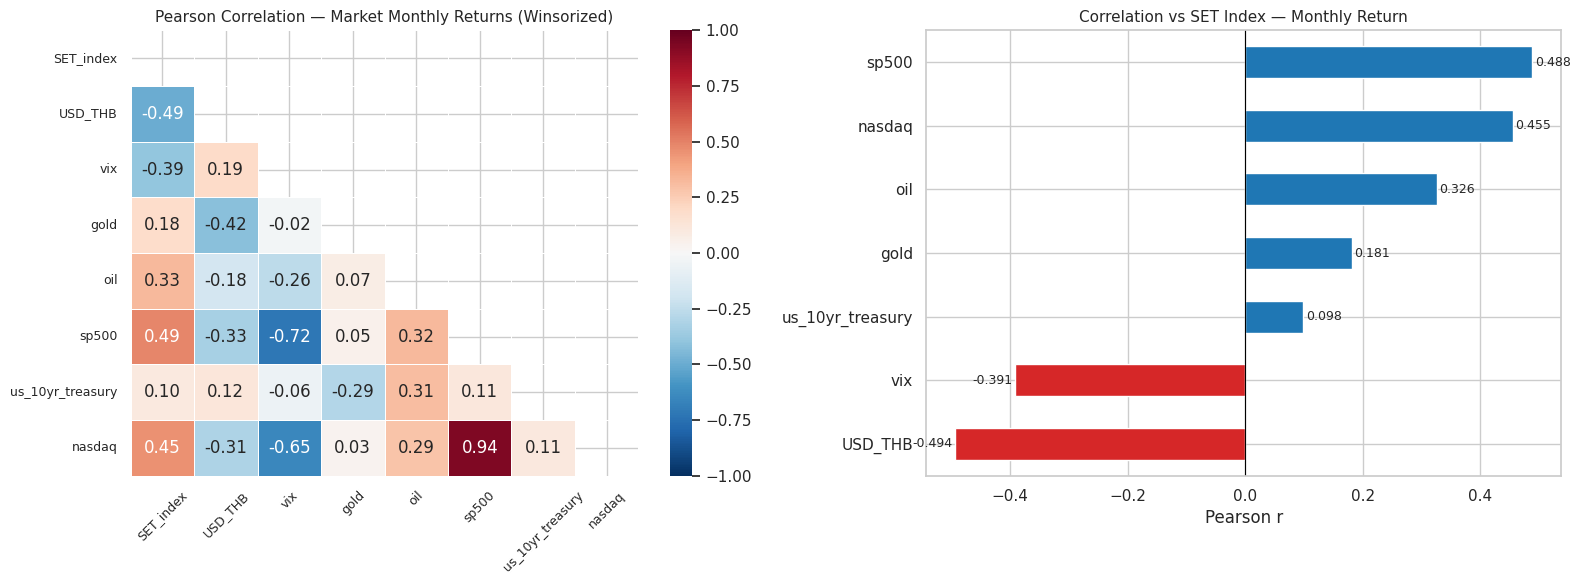

Top 8 correlated pairs (monthly returns):
asset_a   asset_b      corr
 nasdaq     sp500  0.935213
  sp500       vix -0.720574
 nasdaq       vix -0.649181
USD_THB SET_index -0.493764
  sp500 SET_index  0.488339
 nasdaq SET_index  0.454733
   gold   USD_THB -0.418873
    vix SET_index -0.391179


In [3]:
corr_mkt = market_ret.corr()
mask = np.triu(np.ones_like(corr_mkt, dtype=bool))

# Clean column labels (remove _ret_m suffix)
labels = [c.replace('_ret_m', '') for c in corr_mkt.columns]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: heatmap
sns.heatmap(corr_mkt, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, vmin=-1, vmax=1, ax=axes[0],
            xticklabels=labels, yticklabels=labels)
axes[0].set_title('Pearson Correlation — Market Monthly Returns (Winsorized)', fontsize=11)
axes[0].tick_params(axis='x', rotation=45, labelsize=9)
axes[0].tick_params(axis='y', rotation=0,  labelsize=9)

# Right: correlation vs SET_index (bar chart)
set_corr = corr_mkt['SET_index_ret_m'].drop('SET_index_ret_m').sort_values()
colors = ['tab:red' if v < 0 else 'tab:blue' for v in set_corr]
set_corr.index = [i.replace('_ret_m','') for i in set_corr.index]
set_corr.plot(kind='barh', ax=axes[1], color=colors)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Correlation vs SET Index — Monthly Return', fontsize=11)
axes[1].set_xlabel('Pearson r')
for bar, val in zip(axes[1].patches, set_corr):
    axes[1].text(val + (0.005 if val >= 0 else -0.005),
                 bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center',
                 ha='left' if val >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()

pairs = (
    corr_mkt.where(~mask).stack()
    .reset_index()
    .rename(columns={'level_0': 'asset_a', 'level_1': 'asset_b', 0: 'corr'})
    .sort_values('corr', key=abs, ascending=False)
)
pairs['asset_a'] = pairs['asset_a'].str.replace('_ret_m','')
pairs['asset_b'] = pairs['asset_b'].str.replace('_ret_m','')
print('Top 8 correlated pairs (monthly returns):')
print(pairs.head(8).to_string(index=False))


## 2. Lagged Correlation — ตัวแปรไหนนำ / ตาม SET Index

**lag < 0 → X นำหน้า SET (leading indicator)** | lag > 0 → X ตามหลัง SET

### 2A: Market Signals (Daily Returns — 10-day lag window)

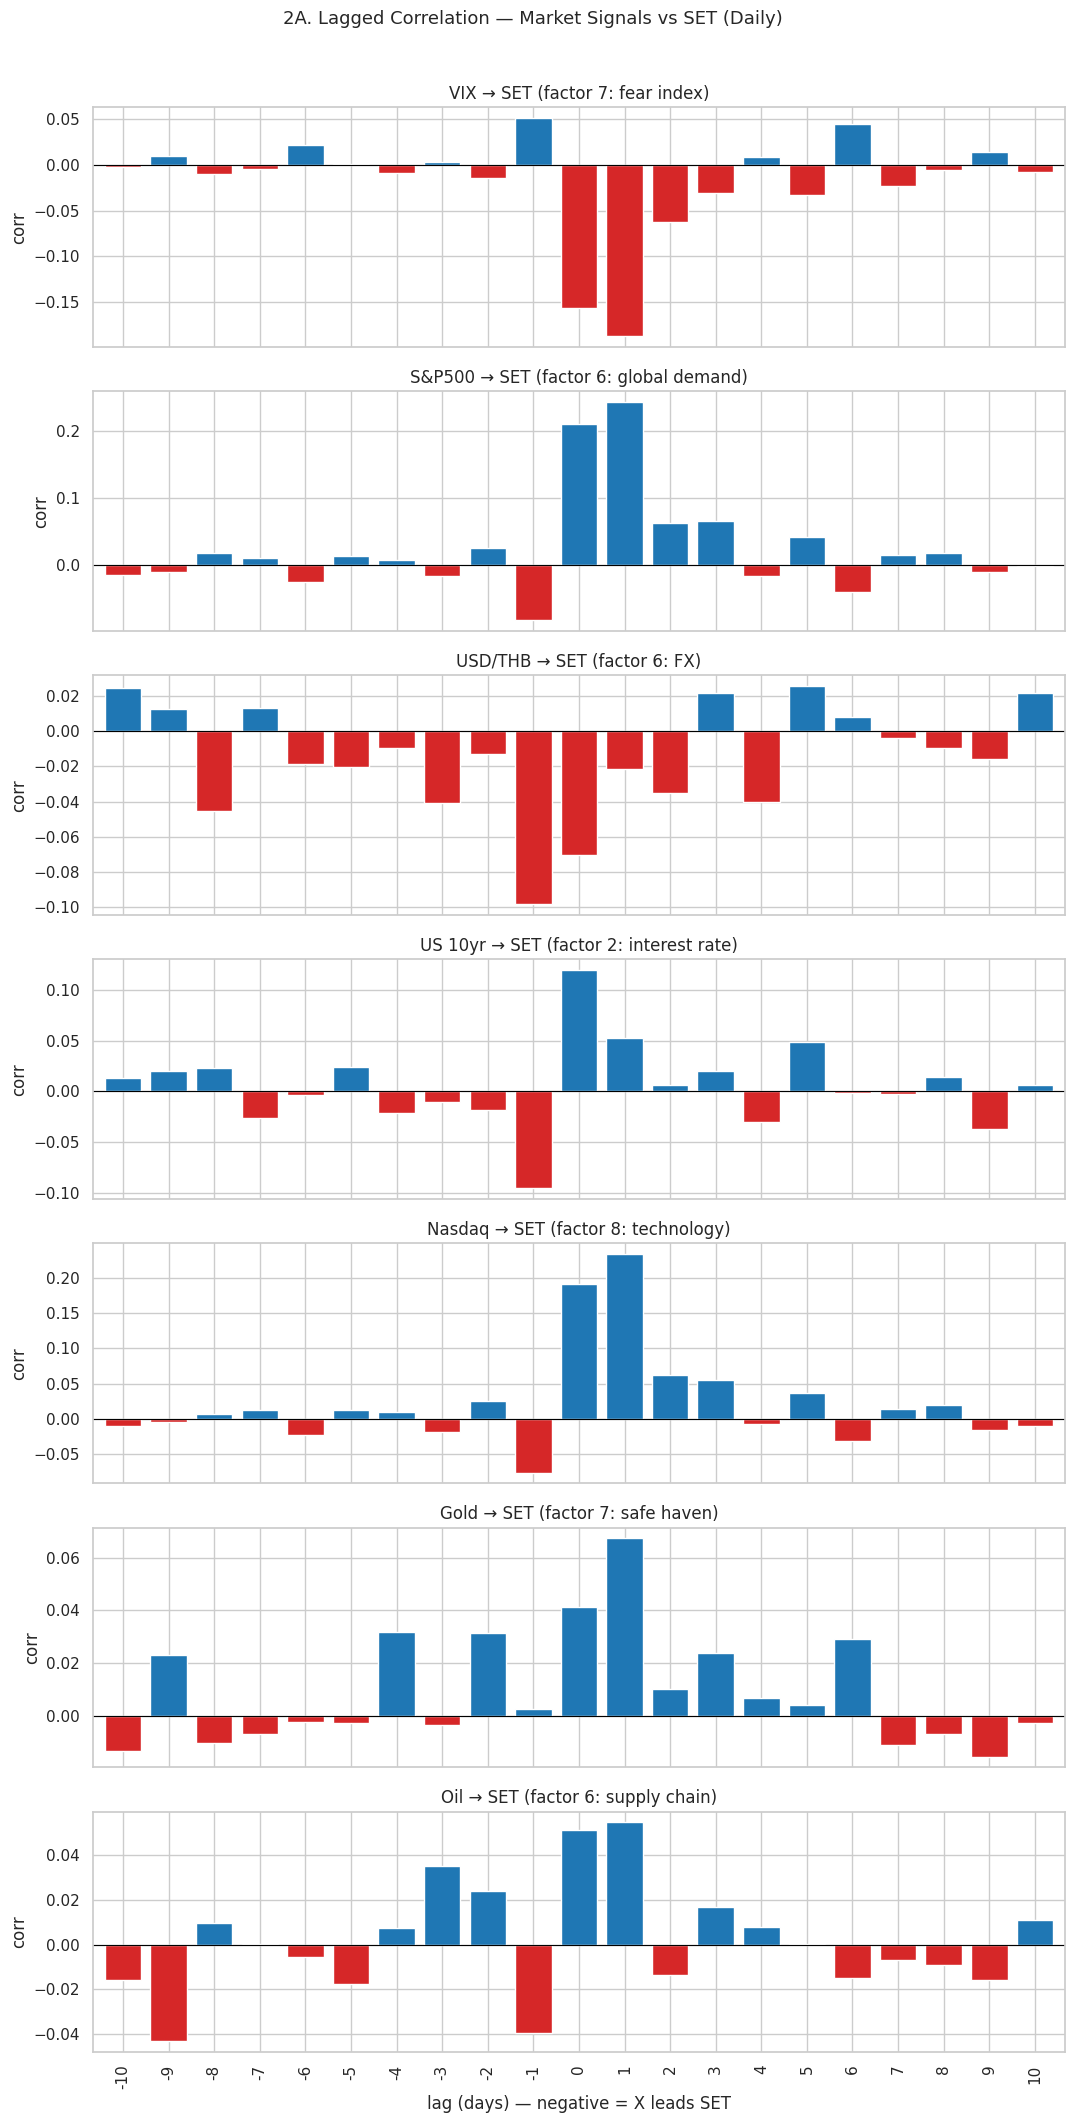

In [4]:
def lagged_corr(x, y, max_lag=10):
    lags = range(-max_lag, max_lag + 1)
    return pd.Series([x.corr(y.shift(-lag)) for lag in lags], index=lags)

# 2A: Market signals daily
lag_pairs_market = [
    ('vix',              'SET_index', 'VIX → SET (factor 7: fear index)'),
    ('sp500',            'SET_index', 'S&P500 → SET (factor 6: global demand)'),
    ('USD_THB',          'SET_index', 'USD/THB → SET (factor 6: FX)'),
    ('us_10yr_treasury', 'SET_index', 'US 10yr → SET (factor 2: interest rate)'),
    ('nasdaq',           'SET_index', 'Nasdaq → SET (factor 8: technology)'),
    ('gold',             'SET_index', 'Gold → SET (factor 7: safe haven)'),
    ('oil',              'SET_index', 'Oil → SET (factor 6: supply chain)'),
]

fig, axes = plt.subplots(len(lag_pairs_market), 1,
                          figsize=(11, 3 * len(lag_pairs_market)), sharex=True)

for ax, (x_col, y_col, label) in zip(axes, lag_pairs_market):
    lc = lagged_corr(daily_ret[x_col], daily_ret[y_col])
    lc.plot(kind='bar', ax=ax,
            color=['tab:red' if v < 0 else 'tab:blue' for v in lc], width=0.8)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(label)
    ax.set_ylabel('corr')

axes[-1].set_xlabel('lag (days) — negative = X leads SET')
plt.suptitle('2A. Lagged Correlation — Market Signals vs SET (Daily)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


### 2B: FRED Monthly Indicators vs SET — Monthly Lag (6-month window)

ใช้ monthly % change ของ FRED เทียบกับ SET monthly return — lag ใน unit เดือน

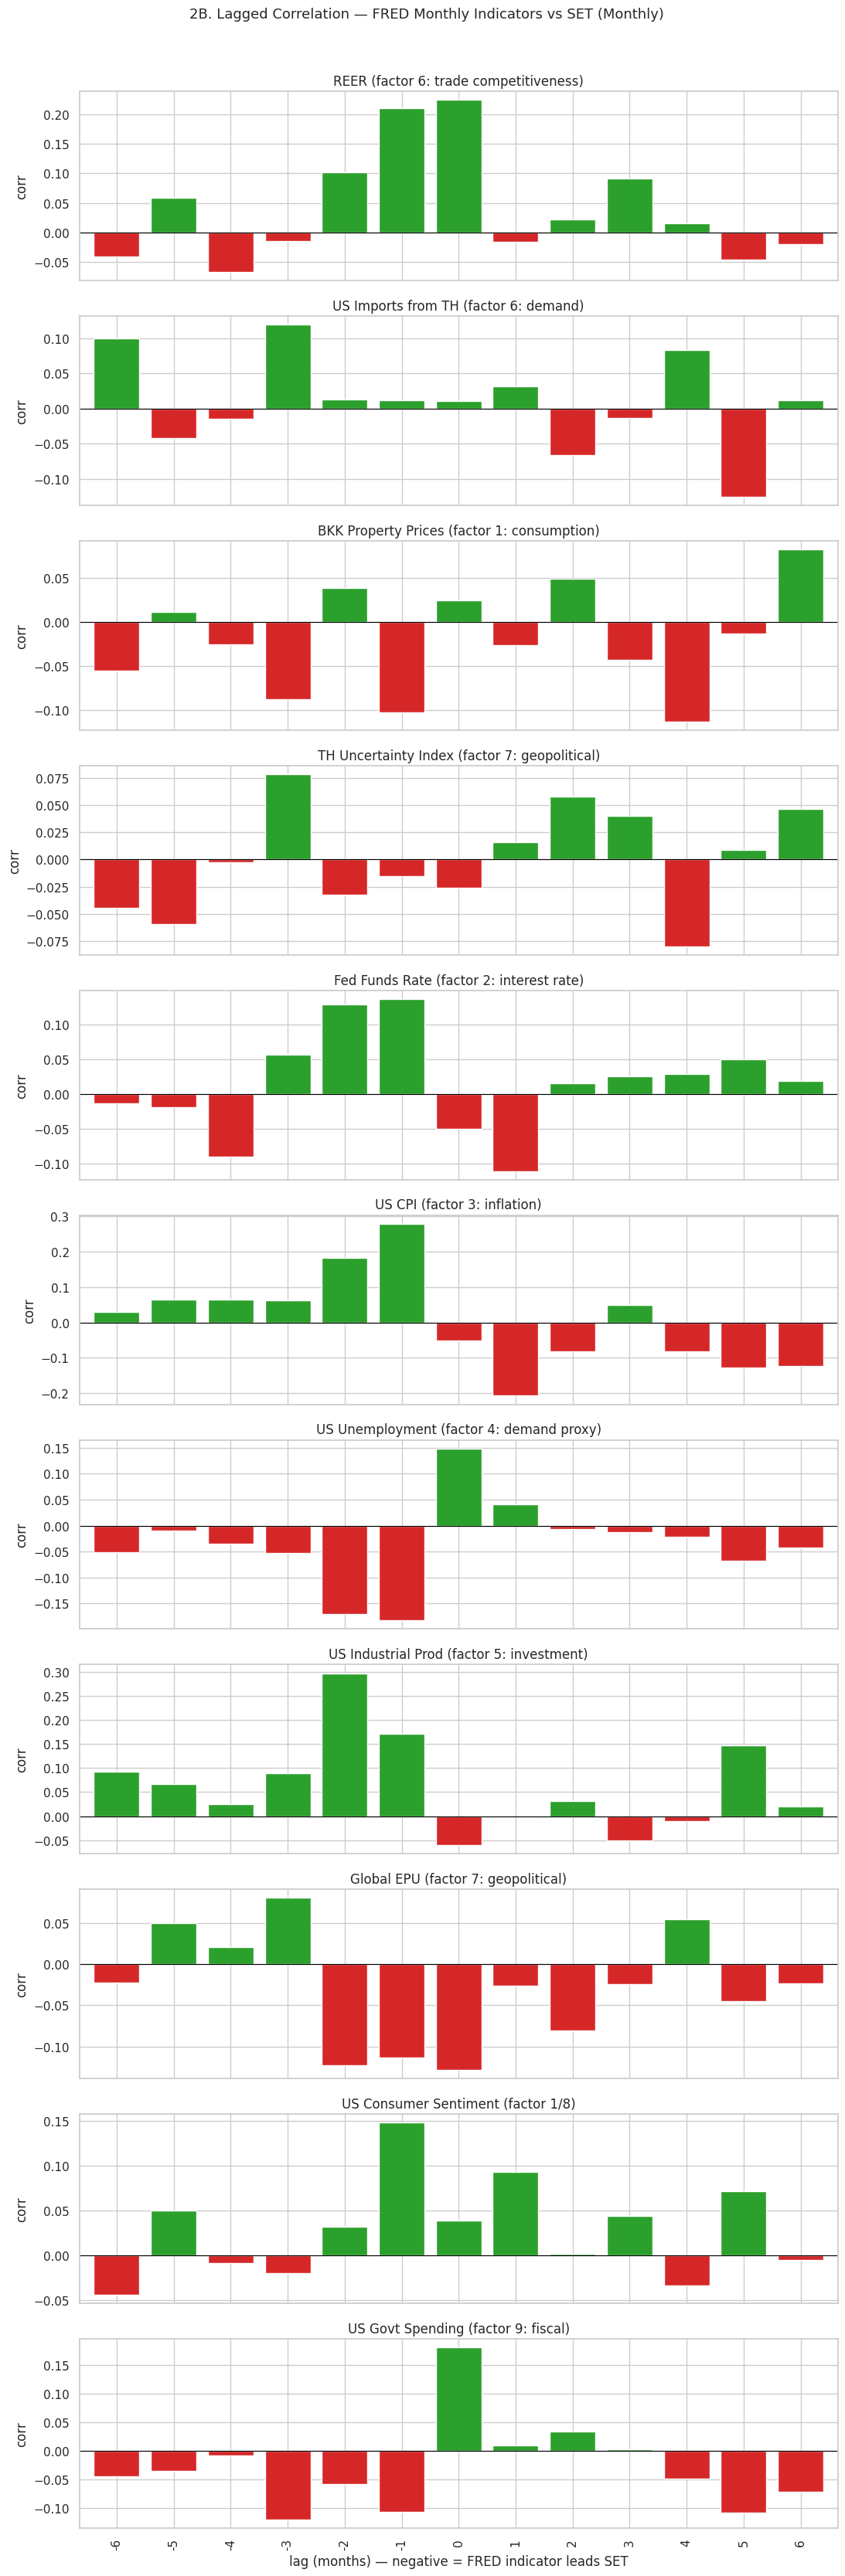

In [5]:
# Align SET monthly return with FRED monthly returns
set_ret_m = market_ret['SET_index_ret_m'].dropna()

FRED_LABELS = {
    'th_exchange_rate_real': 'REER (factor 6: trade competitiveness)',
    'th_us_imports':         'US Imports from TH (factor 6: demand)',
    'th_property_prices':    'BKK Property Prices (factor 1: consumption)',
    'th_uncertainty':        'TH Uncertainty Index (factor 7: geopolitical)',
    'us_fed_funds_rate':     'Fed Funds Rate (factor 2: interest rate)',
    'us_cpi_monthly':        'US CPI (factor 3: inflation)',
    'us_unemployment':       'US Unemployment (factor 4: demand proxy)',
    'us_industrial_prod':    'US Industrial Prod (factor 5: investment)',
    'global_uncertainty':    'Global EPU (factor 7: geopolitical)',
    'us_consumer_sentiment': 'US Consumer Sentiment (factor 1/8)',
    'us_govt_spending':      'US Govt Spending (factor 9: fiscal)',
}

max_lag_m = 6
fig, axes = plt.subplots(len(FRED_LABELS), 1,
                          figsize=(11, 3 * len(FRED_LABELS)), sharex=True)

for ax, (col, label) in zip(axes, FRED_LABELS.items()):
    x = fred_ret[col].dropna()
    aligned = pd.concat([x, set_ret_m], axis=1).dropna()
    if len(aligned) < 10:
        ax.set_title(f'{label} — insufficient data')
        continue
    lc = lagged_corr(aligned[col], aligned['SET_index_ret_m'], max_lag=max_lag_m)
    lc.plot(kind='bar', ax=ax,
            color=['tab:red' if v < 0 else 'tab:green' for v in lc], width=0.8)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(label)
    ax.set_ylabel('corr')

axes[-1].set_xlabel('lag (months) — negative = FRED indicator leads SET')
plt.suptitle('2B. Lagged Correlation — FRED Monthly Indicators vs SET (Monthly)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## 3. Granger Causality

**p < 0.05** = X ช่วยทำนาย Y ได้มากกว่าใช้ประวัติ Y อย่างเดียว → candidate feature สำหรับ model

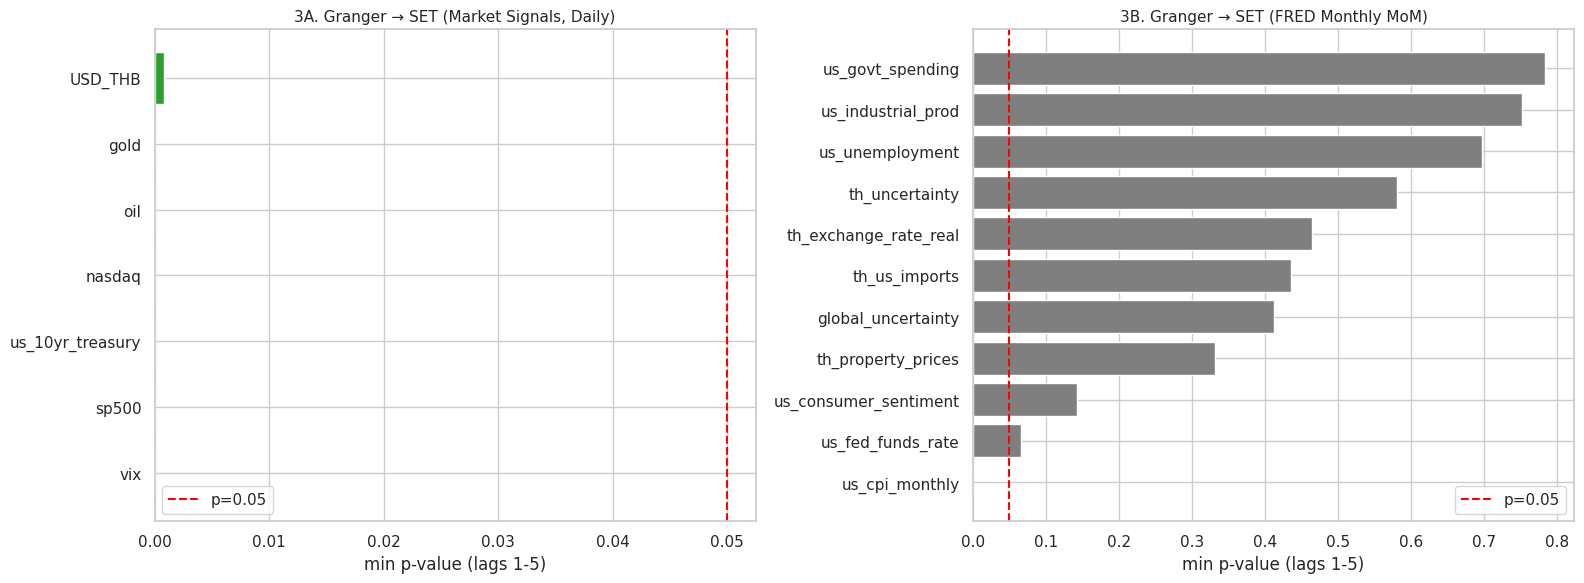

3A — Market signals:
       predictor                      factor  min_pvalue significant
             vix factor 7: geopolitical/fear      0.0000       ✅ yes
           sp500     factor 6: global demand      0.0000       ✅ yes
us_10yr_treasury     factor 2: interest rate      0.0000       ✅ yes
          nasdaq        factor 8: technology      0.0000       ✅ yes
             oil      factor 6: supply chain      0.0000       ✅ yes
            gold        factor 7: safe haven      0.0000       ✅ yes
         USD_THB          factor 6: trade/FX      0.0008       ✅ yes

3B — FRED monthly:
            predictor                         factor  min_pvalue significant
       us_cpi_monthly         factor 3: US inflation      0.0003       ✅ yes
    us_fed_funds_rate             factor 2: Fed rate      0.0660        ❌ no
us_consumer_sentiment       factor 1/8: US sentiment      0.1421        ❌ no
   th_property_prices factor 1: property/consumption      0.3309        ❌ no
   global_uncertainty 

In [6]:
def granger_pvalue(x, y, max_lag=5):
    data = pd.concat([y, x], axis=1).dropna()
    if len(data) < max_lag * 3:
        return np.nan
    try:
        res = grangercausalitytests(data, maxlag=max_lag, verbose=False)
        return min(res[lag][0]['ssr_ftest'][1] for lag in range(1, max_lag + 1))
    except Exception:
        return np.nan

# ── 3A: Market signals (daily) vs SET ─────────────────────────────────────────
MARKET_PREDICTORS = {
    'vix':              'factor 7: geopolitical/fear',
    'sp500':            'factor 6: global demand',
    'USD_THB':          'factor 6: trade/FX',
    'us_10yr_treasury': 'factor 2: interest rate',
    'nasdaq':           'factor 8: technology',
    'gold':             'factor 7: safe haven',
    'oil':              'factor 6: supply chain',
}

results_market = pd.DataFrame([{
    'predictor': p,
    'factor':    label,
    'min_pvalue': round(granger_pvalue(daily_ret[p], daily_ret['SET_index']), 4),
} for p, label in MARKET_PREDICTORS.items()])
results_market['significant'] = results_market['min_pvalue'].apply(
    lambda v: '✅ yes' if v < 0.05 else '❌ no')
results_market = results_market.sort_values('min_pvalue')

# ── 3B: FRED monthly % change vs SET monthly return ────────────────────────────
FRED_PREDICTORS = {
    'th_exchange_rate_real': 'factor 6: REER',
    'th_us_imports':         'factor 6: US→TH demand',
    'th_property_prices':    'factor 1: property/consumption',
    'th_uncertainty':        'factor 7: TH geopolitical',
    'us_fed_funds_rate':     'factor 2: Fed rate',
    'us_cpi_monthly':        'factor 3: US inflation',
    'us_unemployment':       'factor 4: US demand',
    'us_industrial_prod':    'factor 5: US investment',
    'global_uncertainty':    'factor 7: global EPU',
    'us_consumer_sentiment': 'factor 1/8: US sentiment',
    'us_govt_spending':      'factor 9: US fiscal',
}

results_fred = pd.DataFrame([{
    'predictor': p,
    'factor':    label,
    'min_pvalue': round(granger_pvalue(fred_ret[p], set_ret_m, max_lag=4), 4),
} for p, label in FRED_PREDICTORS.items()])
results_fred['significant'] = results_fred['min_pvalue'].apply(
    lambda v: '✅ yes' if v < 0.05 else '❌ no')
results_fred = results_fred.sort_values('min_pvalue')

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, df, title in [
    (axes[0], results_market, '3A. Granger → SET (Market Signals, Daily)'),
    (axes[1], results_fred,   '3B. Granger → SET (FRED Monthly MoM)'),
]:
    colors = ['tab:green' if p < 0.05 else 'tab:gray' for p in df['min_pvalue']]
    ax.barh(df['predictor'], df['min_pvalue'], color=colors)
    ax.axvline(0.05, color='red', linestyle='--', label='p=0.05')
    ax.set_xlabel('min p-value (lags 1-5)')
    ax.set_title(title, fontsize=11)
    ax.legend()

plt.tight_layout()
plt.show()

print('3A — Market signals:')
print(results_market[['predictor','factor','min_pvalue','significant']].to_string(index=False))
print()
print('3B — FRED monthly:')
print(results_fred[['predictor','factor','min_pvalue','significant']].to_string(index=False))


## 4. Macro Correlation — Annual Indicators

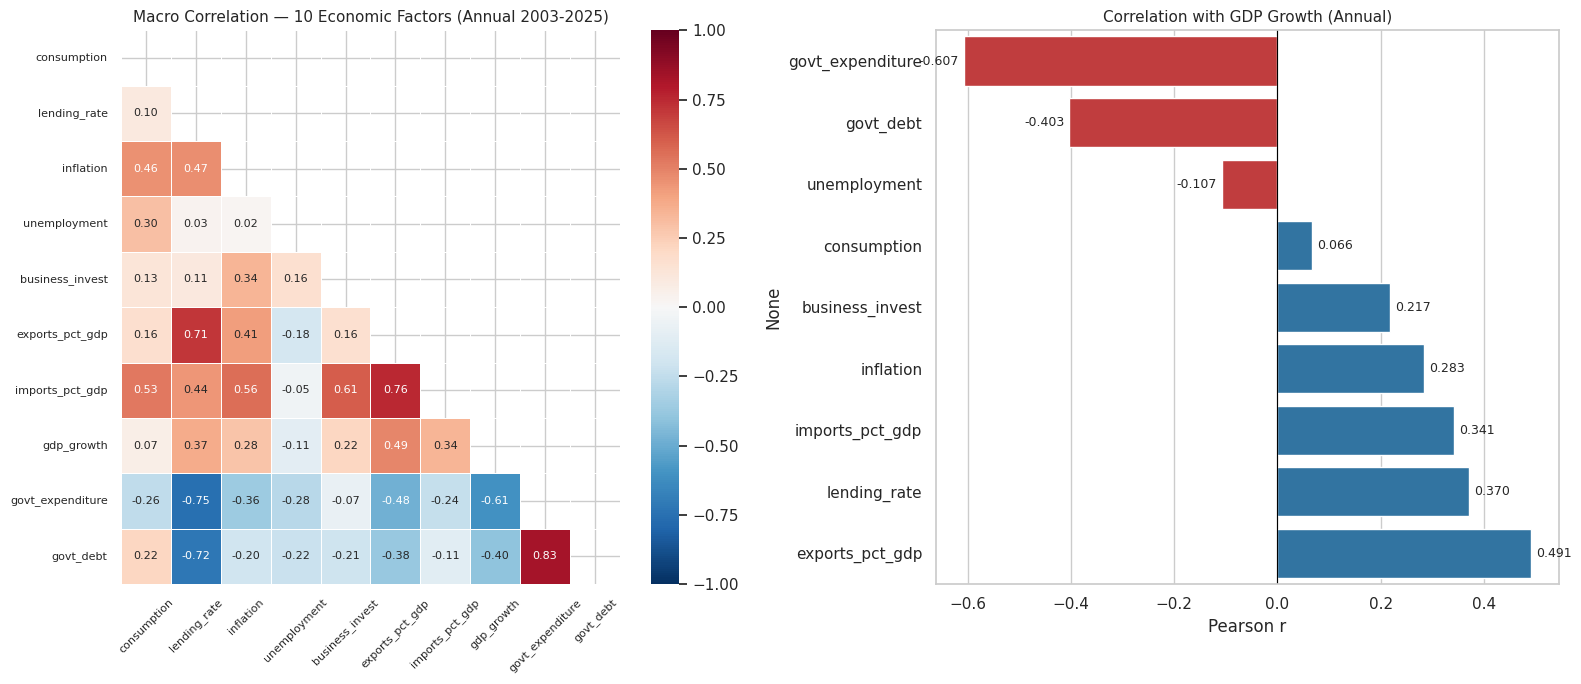


Macro data (2020-2025):
      consumption  lending_rate  inflation  unemployment  business_invest  exports_pct_gdp  imports_pct_gdp  gdp_growth  govt_expenditure  govt_debt
year                                                                                                                                                
2020    53.047600      3.292500  -0.845937         1.099        23.755385        51.494427        46.306317        -6.1         22.831357  50.322781
2021    52.239681      3.060000   1.230395         1.215        28.669036        58.559389        58.693555         1.6         25.132994  58.511454
2022    54.564965      3.138333  -1.610680         0.940        27.858429        65.372764        67.485948         2.7         22.232044  60.349920
2023    57.481430      4.285833   8.478052         0.733        22.460510        65.444563        63.379551         2.2         20.766468  61.124361
2024    58.210625      4.514167   1.365805         0.781        21.580929        

In [7]:
# Macro annual — use clean column names for display
macro_clean = macro.dropna(how='all')
macro_clean.columns = [c.replace('_annual','') for c in macro_clean.columns]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Full correlation heatmap
mask_m = np.triu(np.ones_like(macro_clean.corr(), dtype=bool))
sns.heatmap(macro_clean.corr(), mask=mask_m, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, vmin=-1, vmax=1, ax=axes[0],
            annot_kws={'size': 8})
axes[0].set_title('Macro Correlation — 10 Economic Factors (Annual 2003-2025)', fontsize=11)
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].tick_params(axis='y', rotation=0,  labelsize=8)

# Correlation with gdp_growth
gdp_corr = macro_clean.corr()[['gdp_growth']].drop('gdp_growth').sort_values('gdp_growth')
colors = ['tab:red' if v < 0 else 'tab:blue' for v in gdp_corr['gdp_growth']]
sns.barplot(x='gdp_growth', y=gdp_corr.index, data=gdp_corr.reset_index(),
            palette=colors, ax=axes[1])
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Correlation with GDP Growth (Annual)', fontsize=11)
axes[1].set_xlabel('Pearson r')
for bar, val in zip(axes[1].patches, gdp_corr['gdp_growth']):
    axes[1].text(val + (0.01 if val >= 0 else -0.01),
                 bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center',
                 ha='left' if val >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()

print('\nMacro data (2020-2025):')
print(macro_clean[macro_clean.index.astype(str).str[:4].astype(int) >= 2020].to_string())


## 5. Rolling Correlation — ความสัมพันธ์เปลี่ยนตามเวลา

### 5A: Market Signals (Daily, 60-day window) vs SET
### 5B: FRED Monthly Indicators (12-month window) vs SET

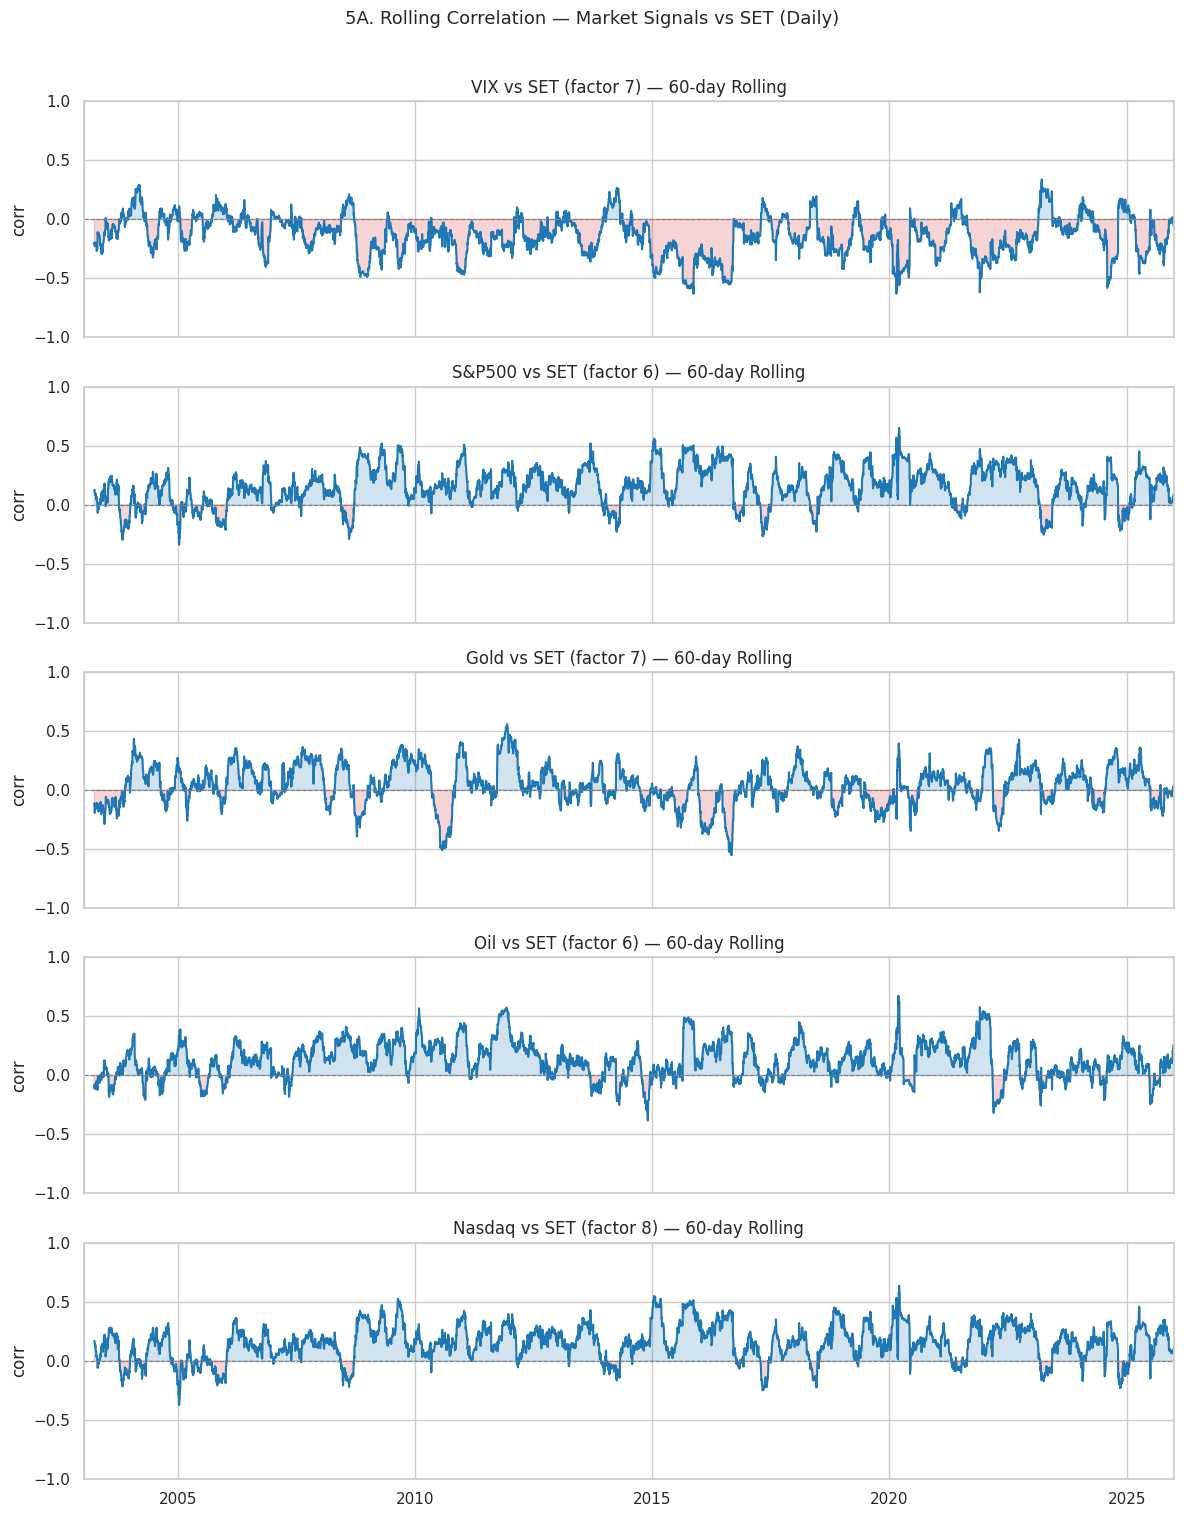

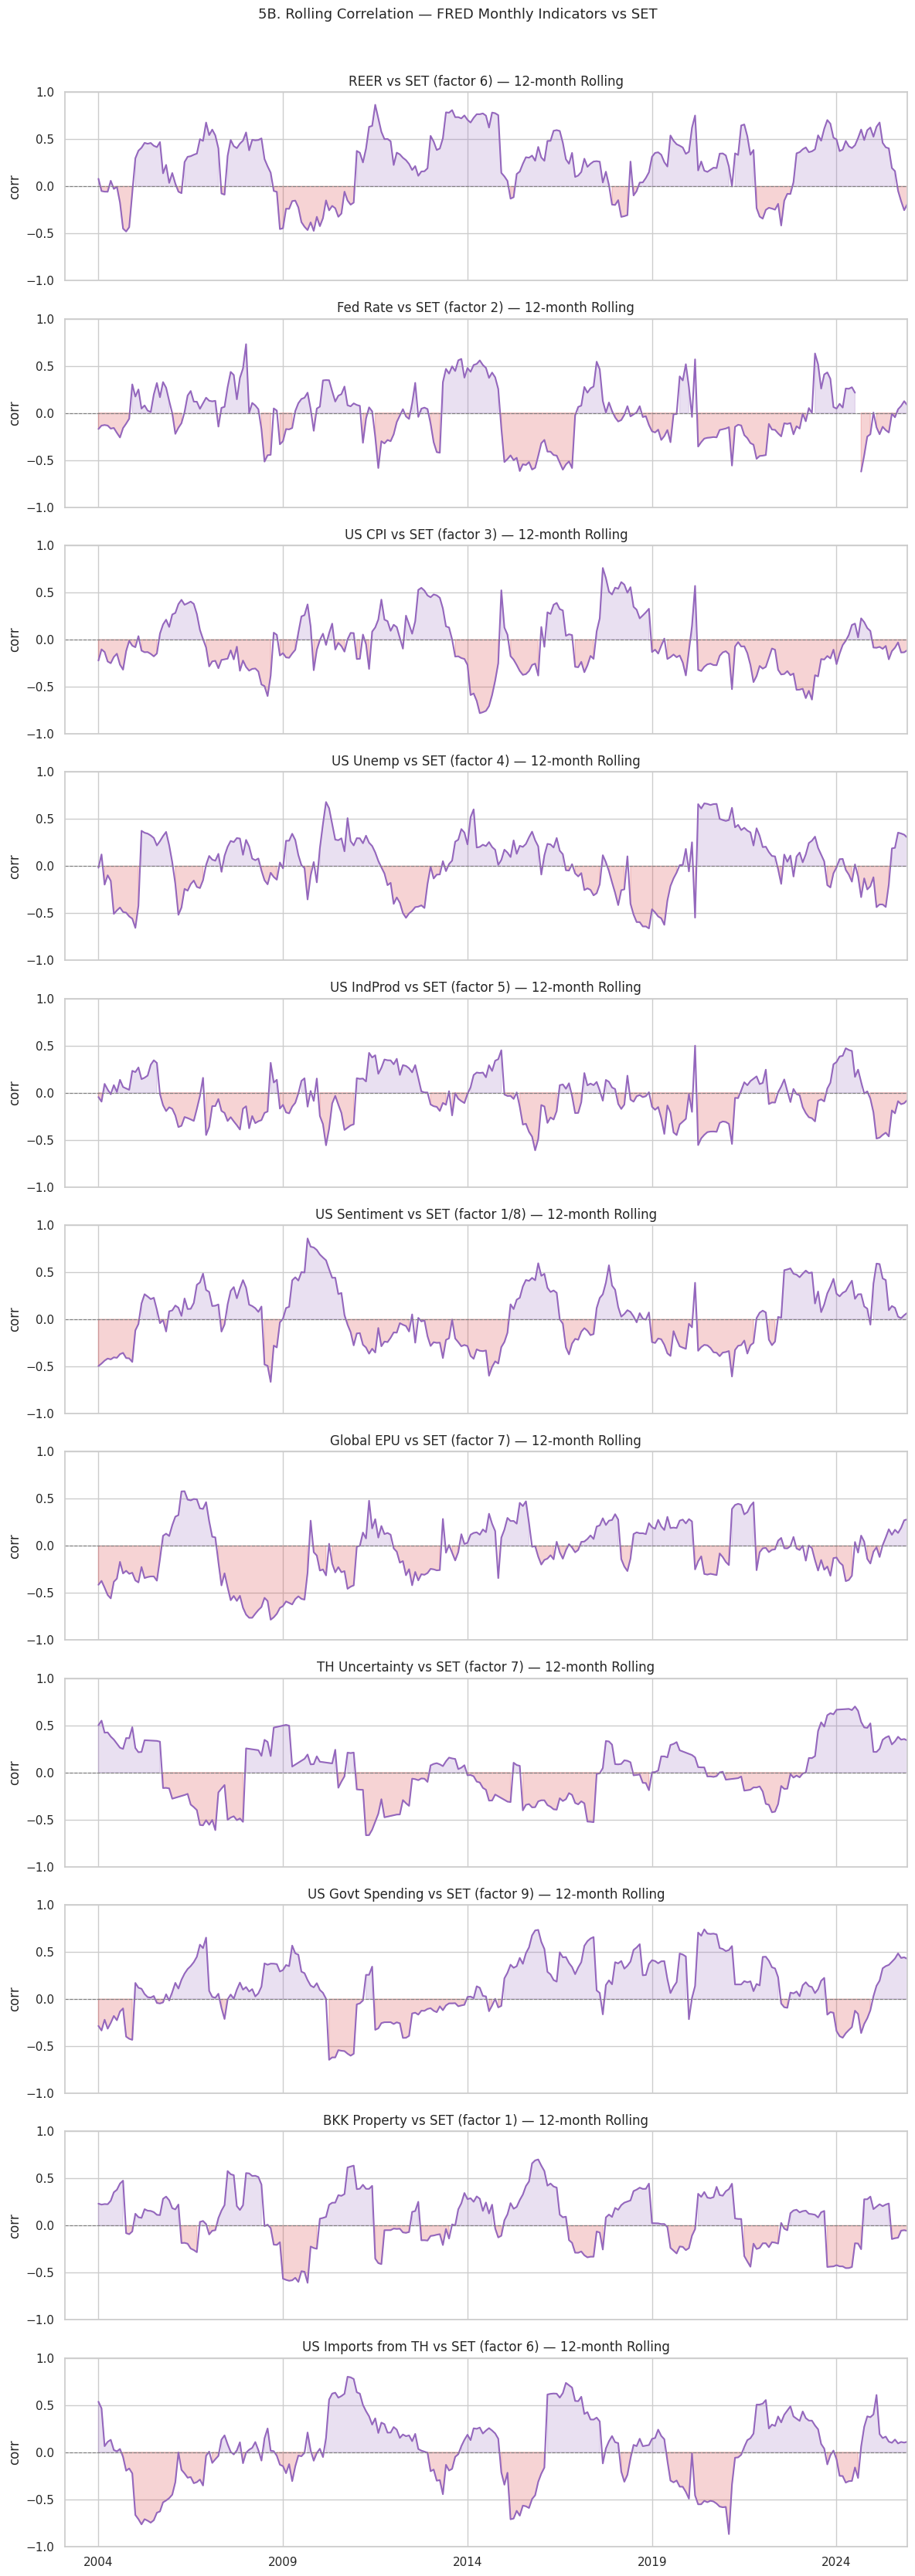

In [8]:
# 5A: Daily market rolling 60-day
window_d = 60
rolling_pairs_daily = [
    ('vix',   'SET_index', 'VIX vs SET (factor 7)'),
    ('sp500', 'SET_index', 'S&P500 vs SET (factor 6)'),
    ('gold',  'SET_index', 'Gold vs SET (factor 7)'),
    ('oil',   'SET_index', 'Oil vs SET (factor 6)'),
    ('nasdaq','SET_index', 'Nasdaq vs SET (factor 8)'),
]

fig, axes = plt.subplots(len(rolling_pairs_daily), 1,
                          figsize=(12, 3 * len(rolling_pairs_daily)), sharex=True)

for ax, (a, b, label) in zip(axes, rolling_pairs_daily):
    rc = daily_ret[a].rolling(window_d).corr(daily_ret[b])
    rc.plot(ax=ax, linewidth=1.5, color='tab:blue')
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.fill_between(rc.index, rc, 0, where=(rc >= 0), alpha=0.2, color='tab:blue')
    ax.fill_between(rc.index, rc, 0, where=(rc <  0), alpha=0.2, color='tab:red')
    ax.set_title(f'{label} — {window_d}-day Rolling')
    ax.set_ylabel('corr')
    ax.set_ylim(-1, 1)

plt.suptitle('5A. Rolling Correlation — Market Signals vs SET (Daily)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# 5B: FRED monthly rolling 12-month
window_m = 12
rolling_pairs_fred = [
    ('th_exchange_rate_real', 'REER vs SET (factor 6)'),
    ('us_fed_funds_rate',     'Fed Rate vs SET (factor 2)'),
    ('us_cpi_monthly',        'US CPI vs SET (factor 3)'),
    ('us_unemployment',       'US Unemp vs SET (factor 4)'),
    ('us_industrial_prod',    'US IndProd vs SET (factor 5)'),
    ('us_consumer_sentiment', 'US Sentiment vs SET (factor 1/8)'),
    ('global_uncertainty',    'Global EPU vs SET (factor 7)'),
    ('th_uncertainty',        'TH Uncertainty vs SET (factor 7)'),
    ('us_govt_spending',      'US Govt Spending vs SET (factor 9)'),
    ('th_property_prices',    'BKK Property vs SET (factor 1)'),
    ('th_us_imports',         'US Imports from TH vs SET (factor 6)'),
]

fig, axes = plt.subplots(len(rolling_pairs_fred), 1,
                          figsize=(12, 3 * len(rolling_pairs_fred)), sharex=True)

for ax, (col, label) in zip(axes, rolling_pairs_fred):
    aligned = pd.concat([fred_ret[col], set_ret_m], axis=1).dropna()
    if len(aligned) < window_m:
        ax.set_title(f'{label} — insufficient data')
        continue
    rc = aligned[col].rolling(window_m).corr(aligned['SET_index_ret_m'])
    rc.plot(ax=ax, linewidth=1.5, color='tab:purple')
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.fill_between(rc.index, rc, 0, where=(rc >= 0), alpha=0.2, color='tab:purple')
    ax.fill_between(rc.index, rc, 0, where=(rc <  0), alpha=0.2, color='tab:red')
    ax.set_title(f'{label} — {window_m}-month Rolling')
    ax.set_ylabel('corr')
    ax.set_ylim(-1, 1)

plt.suptitle('5B. Rolling Correlation — FRED Monthly Indicators vs SET', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## 6. Full Monthly Cross-Correlation — ทุก Dataset vs SET

รวม market monthly returns + FRED monthly MoM % change เป็น dataset เดียว แล้ว:
- **Left:** heatmap ความสัมพันธ์ระหว่างทุกตัวแปร (monthly frequency)
- **Right:** ranked bar chart — ตัวแปรไหน correlate กับ SET มากที่สุด

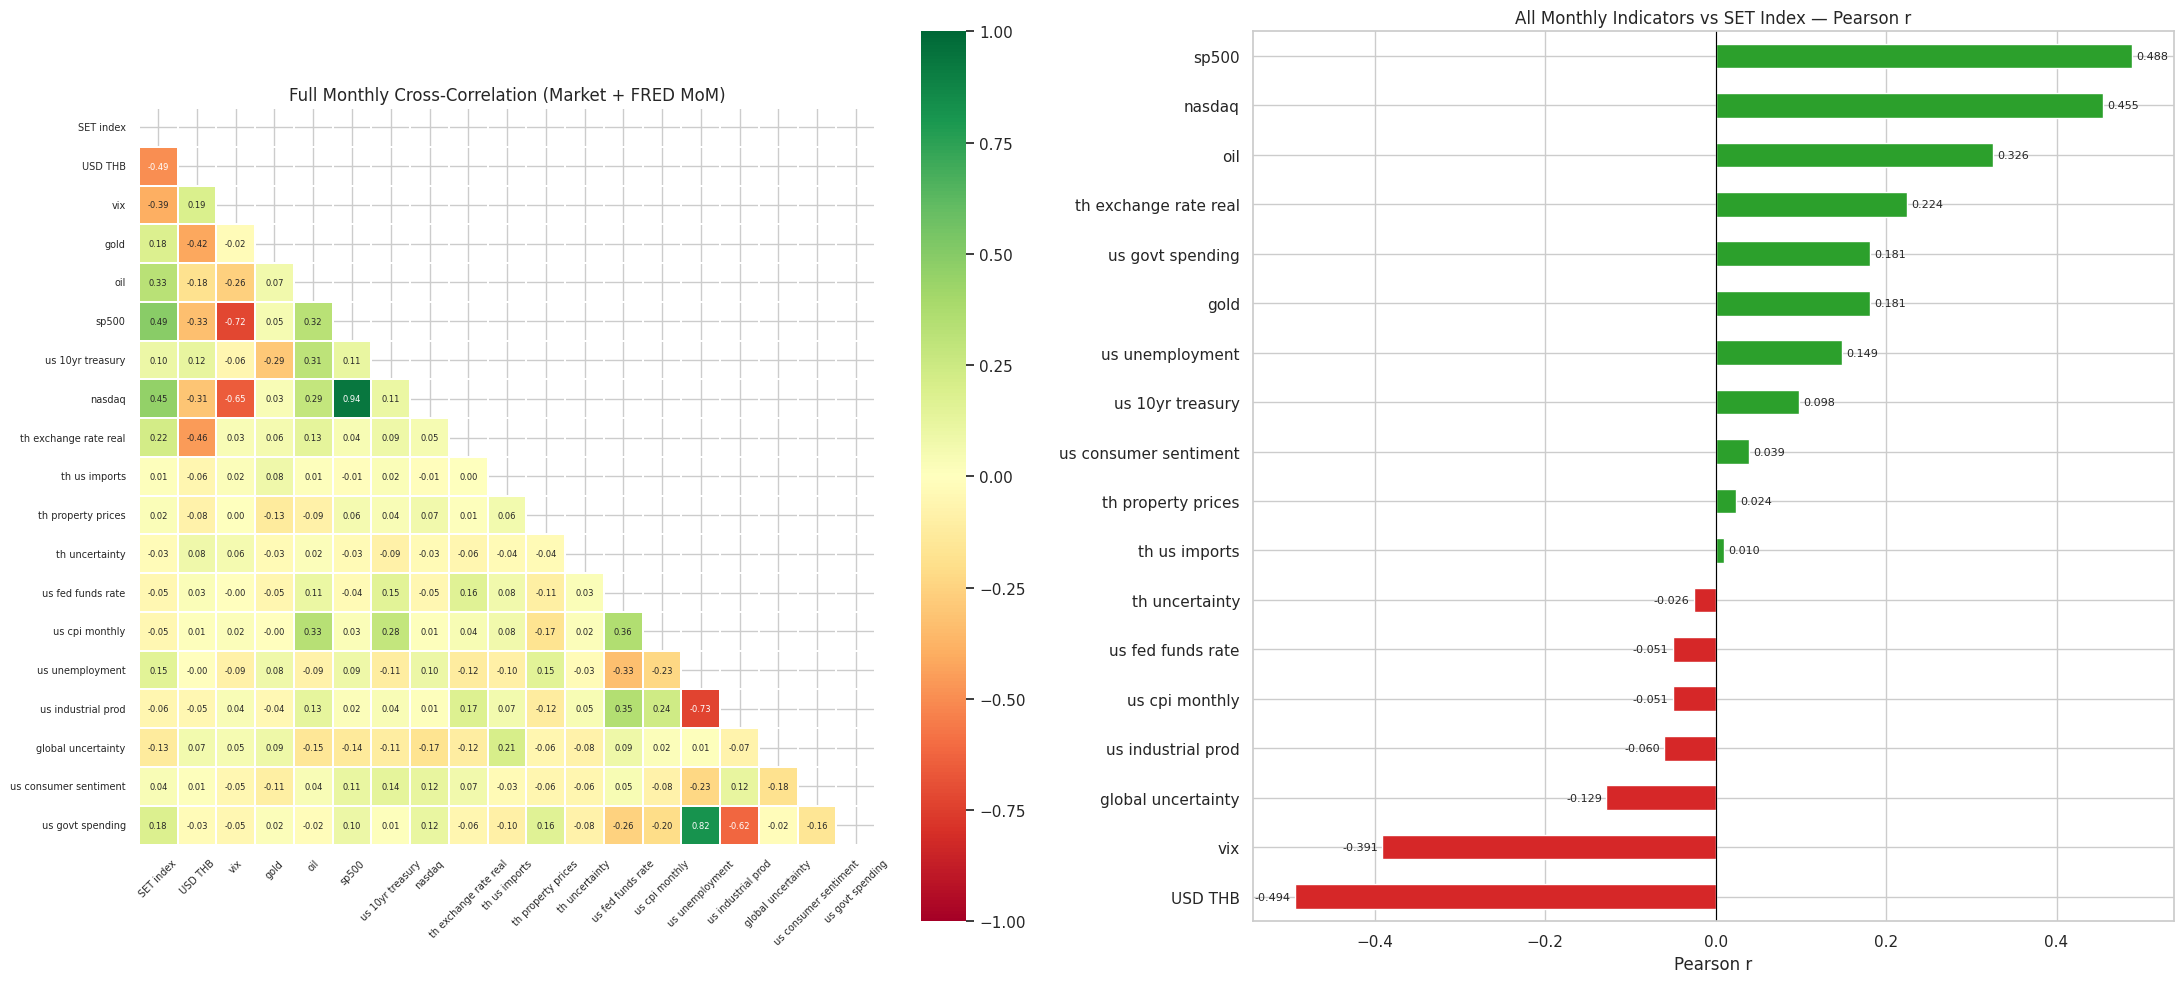

All variables vs SET (monthly) — sorted by |r|:
                       pearson_r
USD THB                  -0.4938
sp500                     0.4883
nasdaq                    0.4547
vix                      -0.3912
oil                       0.3257
th exchange rate real     0.2243
us govt spending          0.1813
gold                      0.1809
us unemployment           0.1485
global uncertainty       -0.1286
us 10yr treasury          0.0980
us industrial prod       -0.0604
us cpi monthly           -0.0506
us fed funds rate        -0.0506
us consumer sentiment     0.0387
th uncertainty           -0.0259
th property prices        0.0243
th us imports             0.0103

Top 10 correlated pairs (all monthly indicators):
                    A                  B         r
               nasdaq              sp500  0.935213
     us govt spending    us unemployment  0.819251
   us industrial prod    us unemployment -0.734190
                sp500                vix -0.720574
               nasd

In [9]:
# ── Combine market monthly returns + FRED monthly % change ─────────────────────
fred_ret_renamed = fred_ret.copy()  # already has descriptive column names

combined_monthly = pd.concat([market_ret, fred_ret_renamed], axis=1).dropna(how='all')

# Clean labels for display
label_map = {c: c.replace('_ret_m','').replace('_',' ') for c in combined_monthly.columns}
combined_display = combined_monthly.rename(columns=label_map)

corr_full = combined_display.corr()
mask_f = np.triu(np.ones_like(corr_full, dtype=bool))

fig, axes = plt.subplots(1, 2, figsize=(22, 10))

# Left: full heatmap
sns.heatmap(
    corr_full, mask=mask_f, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, ax=axes[0],
    linewidths=0.3, square=True,
    annot_kws={'size': 6},
    vmin=-1, vmax=1
)
axes[0].set_title('Full Monthly Cross-Correlation (Market + FRED MoM)', fontsize=12)
axes[0].tick_params(axis='x', rotation=45, labelsize=7)
axes[0].tick_params(axis='y', rotation=0,  labelsize=7)

# Right: all variables vs SET index monthly
set_col = label_map.get('SET_index_ret_m', 'SET index')
if set_col in corr_full.columns:
    corr_vs_set = corr_full[set_col].drop(set_col).sort_values()
    colors = ['tab:red' if v < 0 else 'tab:green' for v in corr_vs_set]
    corr_vs_set.plot(kind='barh', ax=axes[1], color=colors)
    axes[1].axvline(0, color='black', linewidth=0.8)
    axes[1].set_title('All Monthly Indicators vs SET Index — Pearson r', fontsize=12)
    axes[1].set_xlabel('Pearson r')
    for bar, val in zip(axes[1].patches, corr_vs_set):
        axes[1].text(val + (0.005 if val >= 0 else -0.005),
                     bar.get_y() + bar.get_height()/2,
                     f'{val:.3f}', va='center',
                     ha='left' if val >= 0 else 'right', fontsize=8)

plt.tight_layout()
plt.show()

# Summary table
print('All variables vs SET (monthly) — sorted by |r|:')
if set_col in corr_full.columns:
    summary = (corr_full[set_col]
               .drop(set_col)
               .rename('pearson_r')
               .to_frame()
               .assign(abs_r=lambda d: d['pearson_r'].abs())
               .sort_values('abs_r', ascending=False)
               .drop(columns='abs_r'))
    print(summary.round(4).to_string())

# Top 10 most-correlated pairs across the full combined dataset
pairs_full = (
    corr_full.where(~mask_f).stack()
    .reset_index()
    .rename(columns={'level_0':'A','level_1':'B',0:'r'})
    .assign(abs_r=lambda d: d['r'].abs())
    .sort_values('abs_r', ascending=False)
)
print('\nTop 10 correlated pairs (all monthly indicators):')
print(pairs_full.head(10)[['A','B','r']].to_string(index=False))


## Summary

| Section | คำถาม | วิธี | ข้อมูลที่ใช้ |
|---|---|---|---|
| 1 | Market signals relate กันยังไง? | Pearson heatmap (monthly return) | 8 market signals |
| 2A | Market ไหนนำ/ตาม SET? | Lagged corr 10-day (daily) | 7 market signals |
| 2B | FRED indicator ไหนนำ/ตาม SET? | Lagged corr 6-month (monthly) | 11 FRED indicators |
| 3A | Market ทำนาย SET ได้ไหม? | Granger causality (daily) | 7 market signals |
| 3B | FRED ทำนาย SET ได้ไหม? | Granger causality (monthly) | 11 FRED indicators |
| 4 | Macro relate กันยังไง? | Annual correlation heatmap | 10 macro factors |
| 5A | Market rolling corr | 60-day rolling (daily) | 5 key pairs |
| 5B | FRED rolling corr | 12-month rolling (monthly) | 11 FRED indicators |
| 6 | ทุกตัวแปร vs SET? | Full cross-corr heatmap | 8 market + 11 FRED |

**ตัวที่ Granger p < 0.05 → นำไปเป็น features ใน model forecasting**

**Dataset ที่ใช้:** `data/processed/unified_monthly.csv` (276 months × 37 columns, 2003-2025)